<a href="https://colab.research.google.com/github/alaka-deepak/NLP_Engineer_Journey/blob/main/Preprocessing_tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preprocess tweets for sentiment analysis.

In [11]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [2]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [3]:
positive_tweet=twitter_samples.strings('positive_tweets.json')
neg_tweet=twitter_samples.strings('negative_tweets.json')


In [5]:
print("\n 1.Positive: ",len(positive_tweet))
print("\n 2.Negative: ",len(neg_tweet))
print("\n3.Type of Positive Tweets:",type(positive_tweet))
print("\n4. Type of a negative tweet entry os",type(neg_tweet))


 1.Positive:  5000

 2.Negative:  5000

3.Type of Positive Tweets: <class 'list'>

4. Type of a negative tweet entry os <class 'list'>


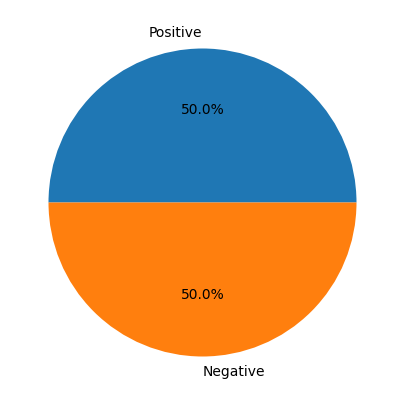

In [8]:
fig=plt.figure(figsize=(5,5))

labels='Positive','Negative'
sizes=[len(positive_tweet),len(neg_tweet)]
plt.pie(sizes,labels=labels,autopct='%1.1f%%')
plt.show()

### Pre-Process

1. Tokenizing the string
2. Lowercasing
3. Removing stop words and punctuation
4. Stemming

In [9]:
tweet=positive_tweet[2277]
print(tweet)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i


In [10]:
# Stop words
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### Remove hyperlinks,  Twitter marks and styles


In [14]:
print('\033[92m' + tweet)
print('\033[94m')

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i



In [17]:
tweet_link=re.sub(r'^RT[\s]+','',tweet)

# Hyperlinks
tweet_link=re.sub(r'https?://[^\s\n\r]+','',tweet_link)
tweet_link = re.sub(r'#', '', tweet_link)

print(tweet_link)


My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 


## Tokenize the string

In [20]:
tweet_link_token=TweetTokenizer(preserve_case=False,strip_handles=True,reduce_len=True).tokenize(tweet_link)
tweet_link_token

['my',
 'beautiful',
 'sunflowers',
 'on',
 'a',
 'sunny',
 'friday',
 'morning',
 'off',
 ':)',
 'sunflowers',
 'favourites',
 'happy',
 'friday',
 'off',
 '…']

In [21]:
# Lowercasing
tweet_link_token=[word.lower() for word in tweet_link_token if word.isalpha()]
tweet_link_token

['my',
 'beautiful',
 'sunflowers',
 'on',
 'a',
 'sunny',
 'friday',
 'morning',
 'off',
 'sunflowers',
 'favourites',
 'happy',
 'friday',
 'off']

In [22]:
# Remove stop words and punctuation
stop_words=stopwords.words('english')
tweet_link_token=[word for word in tweet_link_token if word not in stop_words and word not in string.punctuation]
tweet_link_token

['beautiful',
 'sunflowers',
 'sunny',
 'friday',
 'morning',
 'sunflowers',
 'favourites',
 'happy',
 'friday']

In [27]:
tweet_stemming=[PorterStemmer().stem(word) for word in tweet_link_token]
tweet_stemming

['beauti',
 'sunflow',
 'sunni',
 'friday',
 'morn',
 'sunflow',
 'favourit',
 'happi',
 'friday']

### vectorization

In [34]:
from sklearn.feature_extraction.text  import CountVectorizer
vectorizer=CountVectorizer()
x=vectorizer.fit_transform(tweet_stemming)
print(x.toarray())
print(x.get_shape())
print(vectorizer.vocabulary_)

[[1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0]
 [0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0]]
(9, 7)
{'beauti': 0, 'sunflow': 5, 'sunni': 6, 'friday': 2, 'morn': 4, 'favourit': 1, 'happi': 3}
